In [1]:
import os

# change directory one up 
os.chdir('..')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_and_concat_shift_files(folder_path, prefix, column_name, pos=-1):
    """
    Load CSV files from folder_path that start with prefix, sort them based on the number
    at the end of the filename, add a column with that number, and concatenate all into a single DataFrame.
    
    Args:
        folder_path (str): Path to the folder containing the CSV files.
        prefix (str): Prefix of the files to include.
        column_name (str): Name of the new column to store the shift number.
        idx (int): Index of the parameter to shift (default: -1 for last parameter).

    Returns:
        pd.DataFrame: Concatenated DataFrame of all relevant CSVs with shift column added.
    """
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    # sort files by the number at the end
    shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[pos].replace('.csv','')))
    for idx, f in enumerate(shift_files):
        df = pd.read_csv(os.path.join(folder_path, f))
        df[column_name] = float(f.split('_')[-1].replace('.csv',''))
        if idx == 0:
            combined_df = df
        else:
            combined_df = pd.concat([combined_df, df])
    
    return combined_df

def load_and_concat_multi_shift_files(folder_path, prefix, column_name_relevance, column_name_idx):
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    print(shift_files)
    # sort files by the number at the end
    shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[-2].replace('.csv','')))
    shift_files = sorted(shift_files, key=lambda x: float(x.split('idx')[-1].replace('.csv','')))
    for idx, f in enumerate(shift_files):
        df = pd.read_csv(os.path.join(folder_path, f))
        df[column_name_relevance] = float(f.split('_')[-2].replace('.csv',''))
        df[column_name_idx] = int(f.split('idx')[-1].replace('.csv',''))
        if idx == 0:
            combined_df = df
        else:
            combined_df = pd.concat([combined_df, df])
    return combined_df# plot the relevance shift for each param idx, taking the mean shift of relevance compared to shift 0

def plot_mean_relevance_shift_box(multi_relevance_df, temperature):
    for idx in range(10):
        subset = multi_relevance_df[multi_relevance_df['param_idx'] == idx]
        baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        
        diff_df = pd.DataFrame()
        for shift in subset['relevance_shift'].unique():
            values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df[shift] = values - baseline  # element-wise difference
        
        plt.figure(figsize=(12, 6))
        diff_df.boxplot(grid=True)
        
        plt.xlabel('Relevance Parameter Shift')
        plt.ylabel('Difference in Relevance Compared to Shift 0')
        plt.title(f'Distribution of Element-wise Differences Across Parameter Shifts for Param Index {idx} and temperature {temperature}')
        plt.show()

# plot the plot as a line plot instead of boxplot, showing mean and std
def plot_mean_relevance_shift_grid(multi_relevance_df, temperature, sampler):
    fig, axes = plt.subplots(2, 5, figsize=(21, 9), sharey=True)
    axes = axes.flatten()

    all_means = []
    all_stds = []

    for idx in range(10):
        ax = axes[idx]
        subset = multi_relevance_df[multi_relevance_df['param_idx'] == idx]
        baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        
        diff_df = pd.DataFrame()
        for shift in subset['relevance_shift'].unique():
            values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df[shift] = values - baseline  # element-wise difference
        
        means = diff_df.mean()
        stds = diff_df.std()
        
        all_means.extend(means.values)
        all_stds.extend(stds.values)

        ax.plot(means.index, means.values, marker='o', label='Mean Difference', linewidth=2)
        ax.fill_between(means.index, means - stds, means + stds, 
                        color='b', alpha=0.2, label='±1 Std Dev')
        
        ax.set_title(f'Param {idx}', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if idx % 5 == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=14)
        if idx >= 5:
            ax.set_xlabel('Relevance Shift', fontsize=14)

    # Adjust y-limits globally (zoom in with 10% margin)
    ymin = min(all_means) - max(all_stds) * 1.1
    ymax = max(all_means) + max(all_stds) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    # Global title
    fig.suptitle(f'Mean Element-wise Differences Across Parameter Shifts (temperature={temperature}, sampler={sampler})',
                 fontsize=20, y=1.02)

    # Put legend below all subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=14, ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

def plot_mean_relevance_shift_all(multi_relevance_dfs, temperatures):
    """
    Plot mean Δ relevance vs shift for each param_idx in a grid,
    overlaying results for multiple temperatures.

    Args:
        multi_relevance_dfs (list[pd.DataFrame]): list of DataFrames, one per temperature
        temperatures (list): list of temperature values (same order as dfs)
    """
    # Determine unique parameter indices dynamically
    all_param_indices = sorted(multi_relevance_dfs[0]['param_idx'].unique())
    n_params = len(all_param_indices)

    # Compute grid layout (max 5 columns)
    n_cols = min(5, n_params)
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows), sharey=True)
    axes = np.array(axes).flatten()



    all_means, all_stds = [], []

    for i, idx in enumerate(all_param_indices):
        ax = axes[i]

        for df, temp in zip(multi_relevance_dfs, temperatures):
            subset = df[df['param_idx'] == idx]
            if subset.empty:
                continue

            # Compute baseline at shift = 0
            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)

            diff_df = pd.DataFrame()
            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()
            stds = diff_df.std()

            # shaded confidence area
            ax.fill_between(means.index, means - stds, means + stds, alpha=0.2, zorder=1)
            # line plot
            ax.plot(means.index, means.values, marker='o', linewidth=2,
                    label=f'T={temp}', zorder=2)

            all_means.extend(means.values)
            all_stds.extend(stds.values)

        ax.set_title(f'Param {idx}', fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if i % n_cols == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=12)
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel('Relevance Shift', fontsize=12)

    # Remove unused subplots (if any)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Consistent y-limits
    if all_means and all_stds:
        ymin = min(all_means) - max(all_stds) * 1.1
        ymax = max(all_means) + max(all_stds) * 1.1
        for ax in axes[:n_params]:
            ax.set_ylim(ymin, ymax)

    # Global title
    fig.suptitle('Mean Element-wise Δ Relevance Across Parameter Shifts (All Temperatures)',
                 fontsize=18, y=1.02)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', fontsize=12,
                   ncol=min(len(temperatures), 5), frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

def plot_performance_grid_all_temps(multi_performance_dfs, temperatures, metric='ndcg@10'):
    """
    Plot metric vs Relevance Shift for each param_idx in a grid,
    overlaying results for multiple temperatures.

    Args:
        multi_performance_dfs (list[pd.DataFrame]): list of DataFrames, one per temperature
        temperatures (list): list of temperature values (same order as dfs)
        metric (str): performance metric to plot (default 'ndcg@10')
    """
    # Determine unique param indices from the first df
    all_param_indices = sorted(multi_performance_dfs[0]['param_idx'].unique())
    n_params = len(all_param_indices)

    # Compute grid size (2 rows if >5 params, else 1 row)
    n_cols = min(5, n_params)
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows), sharey=True)
    axes = np.array(axes).flatten()  # Flatten in case of 2D axes

    for i, idx in enumerate(all_param_indices):
        ax = axes[i]
        for df, temp in zip(multi_performance_dfs, temperatures):
            subset = df[df['param_idx'] == idx]
            if subset.empty:
                continue
            ax.plot(subset['relevance_shift'], subset[metric], marker='o', linewidth=2, label=f'T={temp}')

        ax.set_title(f'Param {idx}', fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if i % n_cols == 0:
            ax.set_ylabel(metric, fontsize=12)
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel('Relevance Shift', fontsize=12)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Global title
    fig.suptitle(f'{metric.upper()} vs Relevance Parameter Shift Across Temperatures',
                 fontsize=18, y=1.02)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', fontsize=12,
                   ncol=len(temperatures), frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


In [32]:
prefix = 'relevance_param_shift_'
folder_path_test_0_n_queries_1 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=1,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0333_n_queries_1 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=1,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0667_n_queries_1 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=1,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_1_n_queries_1 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=1,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0_n_queries_2 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=2,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0333_n_queries_2 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=2,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0667_n_queries_2 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=2,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_1_n_queries_2 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=2,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0_n_queries_10 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=10,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0333_n_queries_10 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=10,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0667_n_queries_10 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=10,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_1_n_queries_10 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=10,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep'




# get performance df
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

multi_performance_df_test_0_n_queries_1 = load_and_concat_multi_shift_files(folder_path_test_0_n_queries_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_n_queries_1 = load_and_concat_multi_shift_files(folder_path_test_0333_n_queries_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_n_queries_1 = load_and_concat_multi_shift_files(folder_path_test_0667_n_queries_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_n_queries_1 = load_and_concat_multi_shift_files(folder_path_test_1_n_queries_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0_n_queries_2 = load_and_concat_multi_shift_files(folder_path_test_0_n_queries_2, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_n_queries_2 = load_and_concat_multi_shift_files(folder_path_test_0333_n_queries_2, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_n_queries_2 = load_and_concat_multi_shift_files(folder_path_test_0667_n_queries_2, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_n_queries_2 = load_and_concat_multi_shift_files(folder_path_test_1_n_queries_2, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0_n_queries_10 = load_and_concat_multi_shift_files(folder_path_test_0_n_queries_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_n_queries_10 = load_and_concat_multi_shift_files(folder_path_test_0333_n_queries_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_n_queries_10 = load_and_concat_multi_shift_files(folder_path_test_0667_n_queries_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_n_queries_10 = load_and_concat_multi_shift_files(folder_path_test_1_n_queries_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')


['test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_2.0_idx0.csv', 'test_clicks_param_shift_-3.0_idx0.csv', 'test_clicks_param_shift_1.0_idx0.csv', 'test_clicks_param_shift_-2.0_idx0.csv', 'test_clicks_param_shift_3.0_idx0.csv']
['test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_2.0_idx0.csv', 'test_clicks_param_shift_-3.0_idx0.csv', 'test_clicks_param_shift_1.0_idx0.csv', 'test_clicks_param_shift_-2.0_idx0.csv', 'test_clicks_param_shift_3.0_idx0.csv']
['test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_2.0_idx0.csv', 'test_clicks_param_shift_-3.0_idx0.csv', 'test_clicks_param_shift_1.0_idx0.csv', 'test_clicks_param_shift_-2.0_idx0.csv', 'test_clicks_param_shift_3.0_idx0.csv']
['test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_2.0_idx0.csv', 'test_clicks_param_shift_-

In [31]:
def plot_mean_relevance_shift_combined(all_multi_relevance_dfs, temperatures, doc_group_sizes):
    n_cols = len(doc_group_sizes)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=True)
    axes = np.array(axes).flatten()

    for ax, dfs, docs in zip(axes, all_multi_relevance_dfs, doc_group_sizes):
        df0 = dfs[0]
        param_idx = df0['param_idx'].unique()[0]  # single param assumption
        all_means, all_stds = [], []

        for df, temp in zip(dfs, temperatures):
            subset = df[df['param_idx'] == param_idx]
            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)

            diff_df = pd.DataFrame()
            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()
            stds = diff_df.std()

            ax.fill_between(means.index, means - stds, means + stds, alpha=0.2)
            ax.plot(means.index, means.values, marker='o', linewidth=2, label=f'T={temp}')

            all_means.extend(means.values)
            all_stds.extend(stds.values)

        ymin = min(all_means) - max(all_stds) * 1.1
        ymax = max(all_means) + max(all_stds) * 1.1
        ax.set_ylim(ymin, ymax)

        ax.set_title(f'{docs} Docs/Group', fontsize=14)
        ax.set_xlabel('Relevance Shift', fontsize=12)
        ax.grid(True, alpha=0.6)
        if ax == axes[0]:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=12,
               ncol=len(temperatures), frameon=False)
    fig.suptitle('Mean Δ Relevance Across Temperatures & Doc Group Sizes', fontsize=18, y=1.05)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


def plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss'):
    n_cols = len(doc_group_sizes)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=True)
    axes = np.array(axes).flatten()

    for ax, dfs, docs in zip(axes, all_multi_performance_dfs, doc_group_sizes):
        df0 = dfs[0]
        param_idx = df0['param_idx'].unique()[0]

        for df, temp in zip(dfs, temperatures):
            subset = df[df['param_idx'] == param_idx]
            ax.plot(subset['relevance_shift'], subset[metric], marker='o', linewidth=2, label=f'T={temp}')

        ax.set_title(f'{docs} Docs/Group', fontsize=14)
        ax.set_xlabel('Relevance Shift', fontsize=12)
        ax.grid(True, alpha=0.6)
        if ax == axes[0]:
            ax.set_ylabel(metric, fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=12,
               ncol=len(temperatures), frameon=False)
    fig.suptitle(f'{metric.upper()} vs Relevance Shift Across Temperatures & Doc Group Sizes', fontsize=18, y=1.05)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


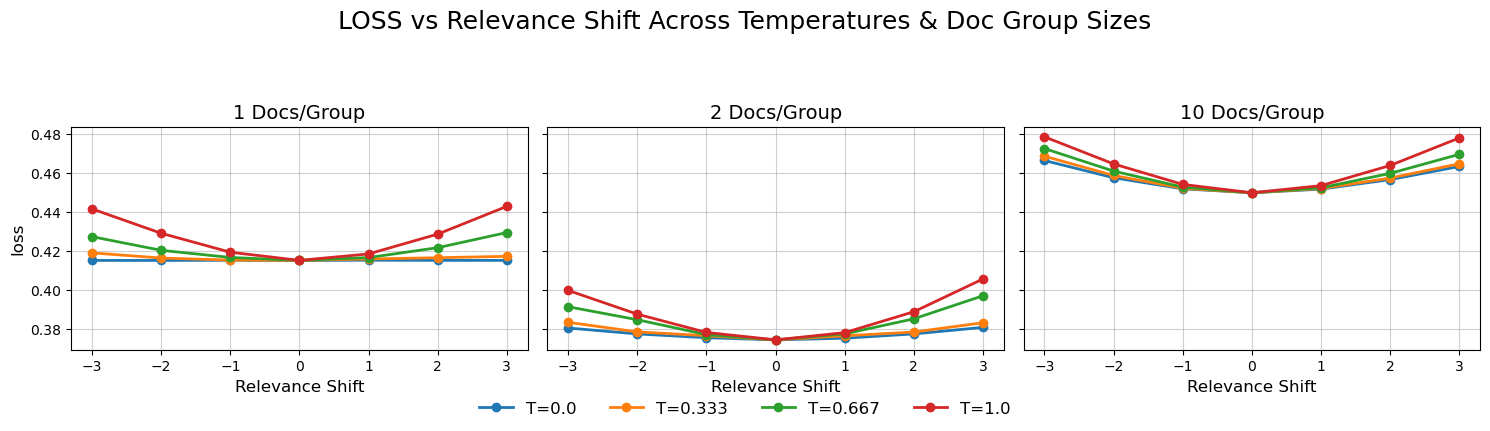

In [35]:
all_multi_relevance_dfs = [
    [multi_performance_df_test_0_n_queries_1, multi_performance_df_test_0333_n_queries_1, multi_performance_df_test_0667_n_queries_1, multi_performance_df_test_1_n_queries_1],
    [multi_performance_df_test_0_n_queries_2, multi_performance_df_test_0333_n_queries_2, multi_performance_df_test_0667_n_queries_2, multi_performance_df_test_1_n_queries_2],
    [multi_performance_df_test_0_n_queries_10, multi_performance_df_test_0333_n_queries_10, multi_performance_df_test_0667_n_queries_10, multi_performance_df_test_1_n_queries_10]
]
    
all_multi_performance_dfs = [
    [multi_performance_df_test_0_n_queries_1, multi_performance_df_test_0333_n_queries_1, multi_performance_df_test_0667_n_queries_1, multi_performance_df_test_1_n_queries_1],
    [multi_performance_df_test_0_n_queries_2, multi_performance_df_test_0333_n_queries_2, multi_performance_df_test_0667_n_queries_2, multi_performance_df_test_1_n_queries_2],
    [multi_performance_df_test_0_n_queries_10, multi_performance_df_test_0333_n_queries_10, multi_performance_df_test_0667_n_queries_10, multi_performance_df_test_1_n_queries_10]
]

temperatures = [0.0, 0.333, 0.667, 1.0]
doc_group_sizes = [1, 2, 10]

# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, temperatures, doc_group_sizes)
plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss')


['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_2.0_idx0.csv']
['relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_-2.0_idx0.cs

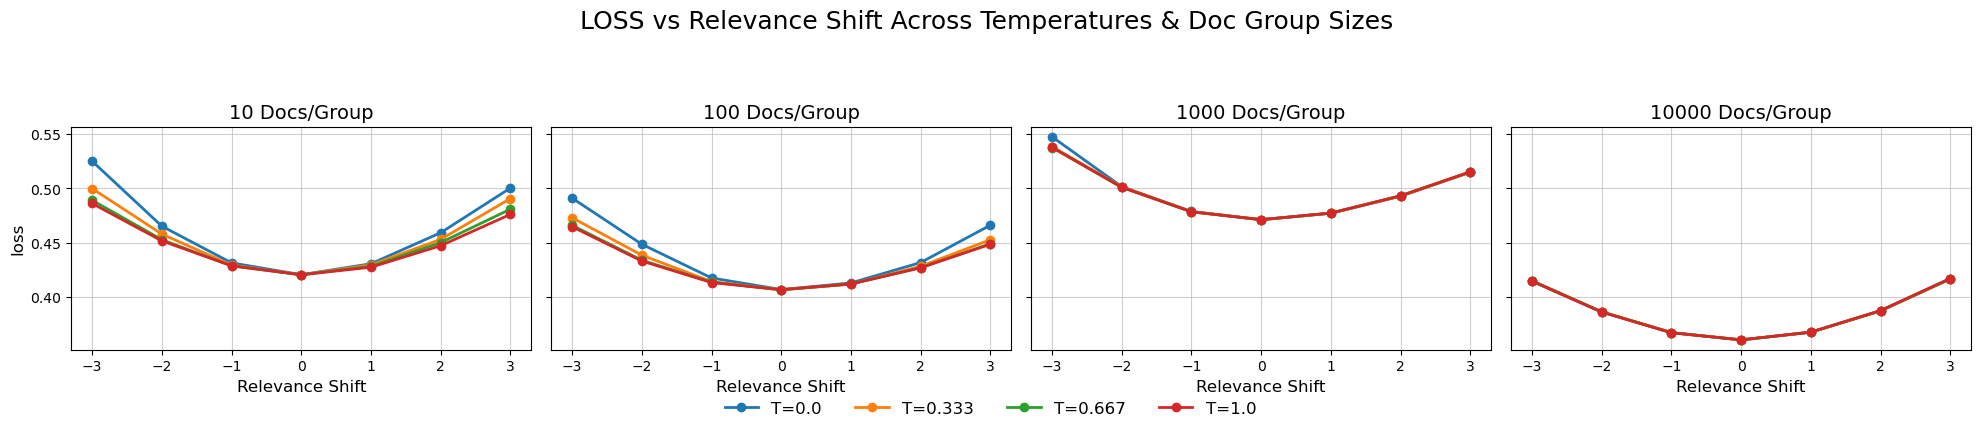

In [27]:
prefix = 'relevance_param_shift_'
folder_path_test_docs_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_docs_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0' 
folder_path_test_docs_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_docs_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'


multi_relevance_df_test_deep_10 = load_and_concat_multi_shift_files(folder_path_test_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_10 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_10 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_10 = load_and_concat_multi_shift_files(folder_path_test_1_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_100 = load_and_concat_multi_shift_files(folder_path_test_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_100 = load_and_concat_multi_shift_files(folder_path_test_1_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_1_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_1_10000, prefix, 'relevance_shift', 'param_idx')

# get performance df
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

multi_performance_df_test = load_and_concat_multi_shift_files(folder_path_test_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1 = load_and_concat_multi_shift_files(folder_path_test_1_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_100 = load_and_concat_multi_shift_files(folder_path_test_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_100 = load_and_concat_multi_shift_files(folder_path_test_1_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_1_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_1_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')

all_multi_relevance_dfs = [
    [multi_relevance_df_test_deep_10, multi_relevance_df_test_0333_deep_10, multi_relevance_df_test_0667_deep_10, multi_relevance_df_test_1_deep_10],
    [multi_relevance_df_test_deep_100, multi_relevance_df_test_0333_deep_100, multi_relevance_df_test_0667_deep_100, multi_relevance_df_test_1_deep_100],
    [multi_relevance_df_test_deep_1000, multi_relevance_df_test_0333_deep_1000, multi_relevance_df_test_0667_deep_1000, multi_relevance_df_test_1_deep_1000],
    [multi_relevance_df_test_deep_10000, multi_relevance_df_test_0333_deep_10000, multi_relevance_df_test_0667_deep_10000, multi_relevance_df_test_1_deep_10000]
]

all_multi_performance_dfs = [
    [multi_performance_df_test, multi_performance_df_test_0333, multi_performance_df_test_0667, multi_performance_df_test_1],
    [multi_performance_df_test_deep_100, multi_performance_df_test_0333_deep_100, multi_performance_df_test_0667_deep_100, multi_performance_df_test_1_deep_100],
    [multi_performance_df_test_deep_1000, multi_performance_df_test_0333_deep_1000, multi_performance_df_test_0667_deep_1000, multi_performance_df_test_1_deep_1000],
    [multi_performance_df_test_deep_10000, multi_performance_df_test_0333_deep_10000, multi_performance_df_test_0667_deep_10000, multi_performance_df_test_1_deep_10000]
]

temperatures = [0.0, 0.333, 0.667, 1.0]
doc_group_sizes = [10, 100, 1000, 10000]

# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, temperatures, doc_group_sizes)
plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss')


['relevance_param_shift_1.0_idx1.csv', 'relevance_param_shift_-3.0_idx1.csv', 'relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_1.0_idx2.csv', 'relevance_param_shift_-3.0_idx2.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_3.0_idx1.csv', 'relevance_param_shift_-1.0_idx1.csv', 'relevance_param_shift_3.0_idx2.csv', 'relevance_param_shift_-1.0_idx2.csv', 'relevance_param_shift_0.0_idx1.csv', 'relevance_param_shift_-2.0_idx1.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_0.0_idx2.csv', 'relevance_param_shift_-2.0_idx2.csv', 'relevance_param_shift_2.0_idx0.csv', 'relevance_param_shift_2.0_idx1.csv', 'relevance_param_shift_2.0_idx2.csv']
['relevance_param_shift_1.0_idx1.csv', 'relevance_param_shift_-3.0_idx1.csv', 'relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_1.0_idx2.csv',

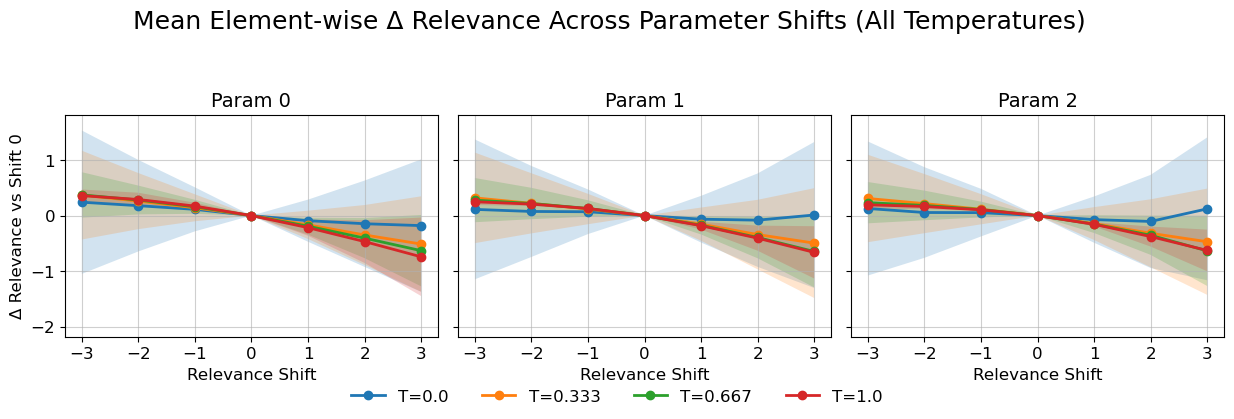

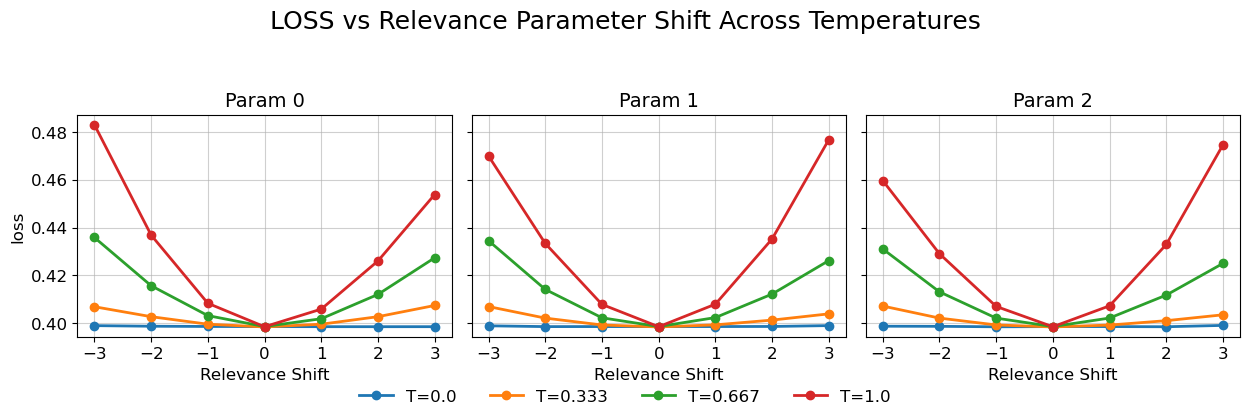

In [7]:
folder_path_test_deep = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_0333 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_0667 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_1 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep'
multi_relevance_df_test_deep = load_and_concat_multi_shift_files(folder_path_test_deep, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_0333 = load_and_concat_multi_shift_files(folder_path_test_deep_0333, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_0667 = load_and_concat_multi_shift_files(folder_path_test_deep_0667, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_1 = load_and_concat_multi_shift_files(folder_path_test_deep_1, prefix, 'relevance_shift', 'param_idx')
# get performance df
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'
multi_performance_df_test_deep = load_and_concat_multi_shift_files(folder_path_test_deep, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_0333 = load_and_concat_multi_shift_files(folder_path_test_deep_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_0667 = load_and_concat_multi_shift_files(folder_path_test_deep_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_1 = load_and_concat_multi_shift_files(folder_path_test_deep_1, prefix_performance_clicks, 'relevance_shift', 'param_idx') 

plot_mean_relevance_shift_all([multi_relevance_df_test_deep, multi_relevance_df_test_deep_0333, multi_relevance_df_test_deep_0667, multi_relevance_df_test_deep_1], [0.0, 0.333, 0.667, 1.0])
plot_performance_grid_all_temps([multi_performance_df_test_deep, multi_performance_df_test_deep_0333, multi_performance_df_test_deep_0667, multi_performance_df_test_deep_1], [0.0, 0.333, 0.667, 1.0], 'loss')

In [78]:

def plot_performance_combined(
    all_multi_performance_dfs,
    temperatures,
    doc_group_sizes,
    metric='loss',
    diff_from_zero=False
):
    """
    Plot performance metric (e.g., loss) vs relevance shift.
    - 4 subplots (one per temperature)
    - each subplot shows multiple lines (one per doc_group_size)
    - optional diff_from_zero to plot Δmetric relative to baseline (shift=0)
    """
    n_cols = len(temperatures)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=True)
    axes = np.array(axes).flatten()

    # iterate over temperatures (outer) and their respective dfs (inner = doc sizes)
    for ax, temp, dfs_for_temp in zip(axes, temperatures, all_multi_performance_dfs):
        all_y_values = []

        for docs, df in zip(doc_group_sizes, dfs_for_temp):
            if df is None or df.empty:
                continue

            param_idx = df['param_idx'].unique()[0]
            subset = df[df['param_idx'] == param_idx].sort_values('relevance_shift')

            if diff_from_zero:
                baseline = subset.loc[subset['relevance_shift'] == 0, metric].mean()
                y_values = subset[metric] - baseline
                label = f"{docs} Queries (Δ)"
            else:
                y_values = subset[metric]
                label = f"{docs} Docs"

            ax.plot(
                subset['relevance_shift'],
                y_values,
                marker='o',
                linewidth=2,
                label=label
            )
            all_y_values.extend(y_values)

        # axis setup
        if len(all_y_values) > 0:
            margin = np.std(all_y_values) * 1.1
            ax.set_ylim(min(all_y_values) - margin, max(all_y_values) + margin)

        ax.set_title(f"T = {temp}", fontsize=14)
        ax.set_xlabel('Relevance Shift', fontsize=12)
        ax.grid(True, alpha=0.6)

        if ax == axes[0]:
            ylabel = f"Δ {metric}" if diff_from_zero else metric
            ax.set_ylabel(ylabel, fontsize=12)

    # shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='lower center',
        fontsize=12,
        ncol=len(doc_group_sizes),
        frameon=False
    )

    # title
    title_metric = f"Δ {metric}" if diff_from_zero else metric
    fig.suptitle(
        f"{title_metric.upper()} vs Relevance Shift — Across Doc Group Sizes & Temperatures",
        fontsize=18,
        y=1.05
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

['test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_2.0_idx0.csv', 'test_clicks_param_shift_-3.0_idx0.csv', 'test_clicks_param_shift_1.0_idx0.csv', 'test_clicks_param_shift_-2.0_idx0.csv', 'test_clicks_param_shift_3.0_idx0.csv']
['test_relevance_param_shift_-3.0_idx0.csv', 'test_relevance_param_shift_1.0_idx0.csv', 'test_relevance_param_shift_3.0_idx0.csv', 'test_relevance_param_shift_-1.0_idx0.csv', 'test_relevance_param_shift_-2.0_idx0.csv', 'test_relevance_param_shift_0.0_idx0.csv', 'test_relevance_param_shift_2.0_idx0.csv']
['test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_2.0_idx0.csv', 'test_clicks_param_shift_-3.0_idx0.csv', 'test_clicks_param_shift_1.0_idx0.csv', 'test_clicks_param_shift_-2.0_idx0.csv', 'test_clicks_param_shift_3.0_idx0.csv']
['test_relevance_param_shift_-3.0_idx0.csv', 'test_relevance_param_shift_1.0_idx0.csv', 'test_relevance_param_shift_3.0_idx0.cs

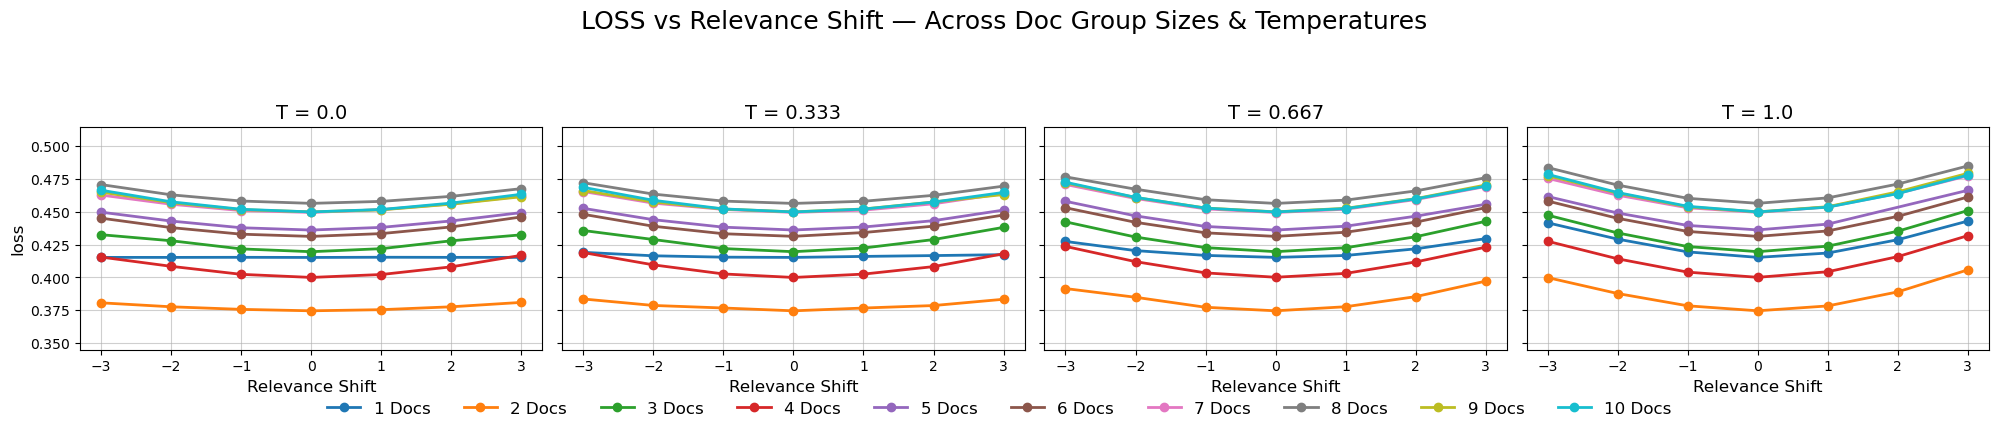

In [81]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

temperatures = [0.0, 0.333, 0.667, 1.0]
doc_group_sizes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

def make_folder_path(n_queries, temp):
    return (
        f"results/relevance_shift_overlap/data=Custom_dataset_deep,docs_per_group=10,experiment=test,"
        f"logging_policy_ranker=deep,logging_policy_sampler=e_greedy,"
        f"num_queries={n_queries},policy_strength=1,policy_temperature={temp},"
        f"random_state=2021,relevance=deep,relevance_tower=deep"
    )

# Containers for all results (now grouped by temperature)
all_multi_performance_dfs = []
all_multi_relevance_dfs = []

# Loop through temperatures first
for temp in temperatures:
    performance_list = []
    relevance_list = []

    for n_queries in doc_group_sizes:
        folder_path = make_folder_path(n_queries, temp)

        # Load performance (clicks)
        perf_df = load_and_concat_multi_shift_files(
            folder_path,
            prefix_performance_clicks,
            'relevance_shift',
            'param_idx'
        )

        # Load relevance
        rel_df = load_and_concat_multi_shift_files(
            folder_path,
            prefix_performance_relevance,
            'relevance_shift',
            'param_idx'
        )

        performance_list.append(perf_df)
        relevance_list.append(rel_df)

    # Append results for this temperature value
    all_multi_performance_dfs.append(performance_list)
    all_multi_relevance_dfs.append(relevance_list)

# ✅ Now you can plot, just reversing the meaning of the axes
# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, doc_group_sizes, temperatures)
plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss', diff_from_zero=False)

Loading data from: results/deep_target_label/data=Custom_dataset_deep,docs_per_group=10,experiment=deep_target_label,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=1,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep
['test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_2.0_idx0.csv', 'test_clicks_param_shift_-3.0_idx0.csv', 'test_clicks_param_shift_1.0_idx0.csv', 'test_clicks_param_shift_-2.0_idx0.csv', 'test_clicks_param_shift_3.0_idx0.csv']
['test_relevance_param_shift_-3.0_idx0.csv', 'test_relevance_param_shift_1.0_idx0.csv', 'test_relevance_param_shift_3.0_idx0.csv', 'test_relevance_param_shift_-1.0_idx0.csv', 'test_relevance_param_shift_-2.0_idx0.csv', 'test_relevance_param_shift_0.0_idx0.csv', 'test_relevance_param_shift_2.0_idx0.csv']
Loading data from: results/deep_target_label/data=Custom_dataset_deep,docs_per_group=10,experiment=deep_target_label,logging_p

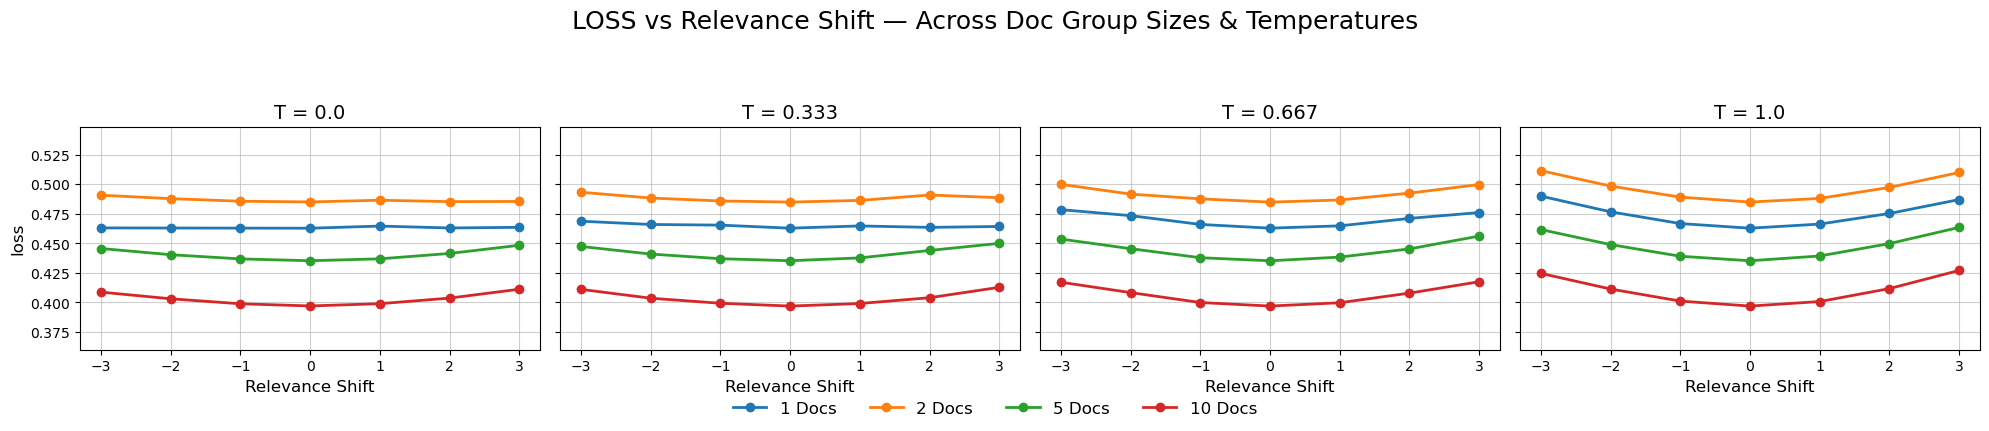

In [82]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

temperatures = [0.0, 0.333, 0.667, 1.0]
doc_group_sizes = [1, 2, 5, 10]

def make_folder_path(n_queries, temp):
    return (
        f"results/deep_target_label/data=Custom_dataset_deep,docs_per_group=10,experiment=deep_target_label,"
        f"logging_policy_ranker=deep,logging_policy_sampler=e_greedy,"
        f"num_queries={n_queries},policy_strength=1,policy_temperature={temp},"
        f"random_state=2021,relevance=deep,relevance_tower=deep"
    )

all_multi_performance_dfs = []
all_multi_relevance_dfs = []

# Loop through temperatures first
for temp in temperatures:
    performance_list = []
    relevance_list = []

    for n_queries in doc_group_sizes:
        folder_path = make_folder_path(n_queries, temp)
        print(f"Loading data from: {folder_path}")
        # Load performance (clicks)
        perf_df = load_and_concat_multi_shift_files(
            folder_path,
            prefix_performance_clicks,
            'relevance_shift',
            'param_idx'
        )

        # Load relevance
        rel_df = load_and_concat_multi_shift_files(
            folder_path,
            prefix_performance_relevance,
            'relevance_shift',
            'param_idx'
        )

        performance_list.append(perf_df)
        relevance_list.append(rel_df)

    # Append results for this temperature value
    all_multi_performance_dfs.append(performance_list)
    all_multi_relevance_dfs.append(relevance_list)

# ✅ Now you can plot, just reversing the meaning of the axes
# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, doc_group_sizes, temperatures)
plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss', diff_from_zero=False)